In [2]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import time
import datetime

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

In [3]:
def generate_mixture_simulated_data(n_units=300, n_obs=50, n_alts=4, n_components=2, n_params=None, n_demos=2, custom_pvec=None, custom_indicators=None, seed=42):
    """
    Generates synthetic panel data for a Hierarchical Multinomial Logit (HMNL) model 
    with a mixture-of-normals prior, based on Rossi et al (2006)

    This function simulates choice data where heterogeneous decision-makers (units) 
    choose among mutually exclusive alternatives over multiple observation periods
    Unit-level preferences (betas) are drawn from a finite mixture of multivariate 
    normal distributions, with the means of these components shifted by 
    observed, mean-centered demographic characteristics

    Parameters
    ----------
    n_units : int, default=300
        The number of heterogeneous decision-making units (e.g., consumers, individuals)
    n_obs : int, default=50
        The number of choice occasions (observations) per unit
    n_alts : int, default=4
        The number of mutually exclusive alternatives available in each choice occasion
    n_components : int, default=2
        The number of latent segments/components (K) in the normal mixture distribution
    n_params : int or None, default=None
        The total number of parameters in the utility function. If None, it defaults 
        to `n_alts` (allowing for n_alts - 1 alternative-specific constants plus 
        1 continuous variable). Must be >= n_alts - 1
    n_demos : int, default=2
        The number of observable demographic characteristics for each unit
    custom_pvec : array-like or None, default=None
        User-defined probabilities for the latent classes. Must be of length `n_components`
    custom_indicators : array-like or None, default=None
        User-defined latent class assignments for each unit. Must be of length `n_units`
    seed : int, default=42
        Random seed for reproducibility

    Returns
    -------
    dict
        A dictionary containing the simulated data and the true underlying parameters:
        - "X" (jax.numpy.ndarray): Design matrices for all choices, shape (n_units * n_obs, n_alts, n_params)
        - "y" (jax.numpy.ndarray): Observed choices (0-indexed), shape (n_units * n_obs,)
        - "Z" (jax.numpy.ndarray): Mean-centered demographic matrix, shape (n_units, n_demos)
        - "unit_idx" (jax.numpy.ndarray): Unit identifiers for panel structure, shape (n_units * n_obs,)
        - "n_units", "n_params", "n_demos", "K", "n_alts": Respective dimension integers
        - "TRUE_DELTA" (numpy.ndarray): True demographic shift matrix
        - "TRUE_BETA" (numpy.ndarray): True unit-level parameters (theta_i/beta_i)
        - "TRUE_PVEC" (numpy.ndarray): True mixture probabilities
        - "TRUE_MU_K" (numpy.ndarray): True mixture component means
        - "TRUE_SIGMA_K" (numpy.ndarray): True mixture component covariance matrices
        - "TRUE_INDICATORS" (numpy.ndarray): True latent class assignments for each unit

    Raises
    ------
    ValueError
        If `n_params` is explicitly set to a value less than `n_alts - 1`
        If `custom_pvec` length does not match `n_components`
        If `custom_indicators` length does not match `n_units`
    """
    np.random.seed(seed)
    
    # ==============================================================================
    # Handle Dimensions & Parameter Initialization
    # ==============================================================================
    # Default n_params allows for (n_alts - 1) Alternative Specific Constants (ASCs) 
    # plus at least 1 continuous variable (e.g., price)
    if n_params is None:
        n_params = n_alts 
        
    # We need enough parameters to identify the base intercepts for the alternatives
    if n_params < n_alts - 1:
        raise ValueError(f"n_params ({n_params}) must be at least n_alts - 1 ({n_alts - 1}) to allow for Alternative Specific Constants (ASCs)")

    n_ascs = n_alts - 1
    n_continuous = n_params - n_ascs

    # ==============================================================================
    # Generate Demographic Data (Z)
    # ==============================================================================
    # Draw raw demographics from a standard normal distribution
    Z = np.random.normal(0, 1, size=(n_units, n_demos))
    
    # Mean-center Z. As per Rossi et al, Z must not include an intercept and 
    # should be centered so the mean of theta (beta) is determined entirely 
    # by the normal mixture component means
    Z = Z - np.mean(Z, axis=0) 

    # ==============================================================================
    # Generate TRUE Global & Mixture Parameters
    # ==============================================================================
    # Delta_true: The matrix of coefficients mapping demographics to utility parameters
    Delta_true = np.random.normal(0, 0.5, size=(n_demos, n_params))

    # true_pvec: The probabilities governing the multinomial distribution of latent classes
    # Check if the user provided custom probabilities
    if custom_pvec is not None:
        if len(custom_pvec) != n_components:
            raise ValueError(f"custom_pvec length ({len(custom_pvec)}) must match n_components ({n_components})")
        true_pvec = np.array(custom_pvec)
        true_pvec = true_pvec / np.sum(true_pvec) # Ensure it sums to exactly 1
    else:
        raw_p = np.random.uniform(0.5, 2.0, n_components)
        true_pvec = raw_p / np.sum(raw_p) # Normalize to sum to 1

    # true_mu_k: The baseline mean utility parameters for each latent segment k
    true_mu_k = np.random.normal(0, 2.0, size=(n_components, n_params))

    # true_Sigma_k: The covariance matrices for the parameters within each segment
    # Generated as diagonal matrices here for simplicity and numeric stability
    true_Sigma_k = np.zeros((n_components, n_params, n_params))
    for k in range(n_components):
        true_Sigma_k[k] = np.diag(np.random.uniform(0.5, 2.0, n_params))

    # ==============================================================================
    # Generate Individual-Level Parameters (Heterogeneity Equation)
    # ==============================================================================
    beta_true = np.zeros((n_units, n_params))
    
    # Draw or assign the latent segment indicator for each unit
    if custom_indicators is not None:
        if len(custom_indicators) != n_units:
            raise ValueError(f"custom_indicators length ({len(custom_indicators)}) must match n_units ({n_units})")
        true_indicators = np.array(custom_indicators)
    else:
        # Draw the latent segment indicator for each unit (ind_i ~ Multinomial(pvec))
        true_indicators = np.random.choice(n_components, size=n_units, p=true_pvec)

    # Calculate theta_i (named beta_true here) for each unit
    for i in range(n_units):
        k = true_indicators[i] # Unit i's assigned mixture component
        
        # Mean for unit i: Demographic shift (Delta' * z_i) + component baseline (mu_k)
        mu_i = Z[i] @ Delta_true + true_mu_k[k]
        
        # Draw the final unit-level parameter vector from the multivariate normal
        beta_true[i] = np.random.multivariate_normal(mu_i, true_Sigma_k[k])

    # ==============================================================================
    # Generate Choice Data (X and y) via Multinomial Logit
    # ==============================================================================
    X_list, y_list, unit_idx_list = [], [], []

    # Iterate over every unit and every choice occasion (panel structure)
    for i in range(n_units):
        for t in range(n_obs):
            # Initialize the design matrix X for choice occasion t
            X_it = np.zeros((n_alts, n_params))

            # Populate Alternative Specific Constants (ASCs)
            # Alternative 0 is implicitly the reference category (all zeros)
            # The remaining alternatives get a dummy variable (1.0) in their respective columns
            for a in range(1, n_alts):
                X_it[a, a - 1] = 1.0

            # Populate the remaining parameter columns with continuous variables (e.g., simulated prices)
            if n_continuous > 0:
                X_it[:, n_ascs:] = np.random.uniform(1.0, 5.0, size=(n_alts, n_continuous))

            # Calculate deterministic utility: U = X * beta
            U_it = X_it @ beta_true[i]
            
            # Map utilities to choice probabilities using the Softmax function
            # We subtract the maximum utility before exponentiating to prevent numeric overflow
            # (computational trick that leaves the resulting probabilities identical)
            U_it_max = np.max(U_it)
            exp_U = np.exp(U_it - U_it_max)
            probs = exp_U / np.sum(exp_U)

            # Simulate observed choice based on the MNL probabilities
            y_it = np.random.choice(n_alts, p=probs)

            # Store data
            X_list.append(X_it)
            y_list.append(y_it)
            unit_idx_list.append(i)

    # Return the simulated dataset and ground-truth parameters
    # Casting data matrices to JAX arrays for downstream modeling with liesel
    return {
        "X": jnp.array(X_list),
        "y": jnp.array(y_list),
        "Z": jnp.array(Z),
        "unit_idx": jnp.array(unit_idx_list),
        "n_units": n_units,
        "n_params": n_params,
        "n_demos": n_demos,
        "K": n_components,
        "n_alts": n_alts,
        "TRUE_DELTA": Delta_true,
        "TRUE_BETA": beta_true,
        "TRUE_PVEC": true_pvec,
        "TRUE_MU_K": true_mu_k,
        "TRUE_SIGMA_K": true_Sigma_k,
        "TRUE_INDICATORS": true_indicators
    }

In [4]:
# We want to force an 80/20 split across our 2 latent classes
controlled_pvec = [0.60, 0.40]

# Run the simulation with the controlled pvec
print("Simulating data with controlled pvec...")
sim_data = generate_mixture_simulated_data(
    n_units=300,
    n_obs=30,
    n_alts=4,
    n_components=2,
    n_demos=2,
    custom_pvec=controlled_pvec, # <-- Passing the custom vector here
    seed=101

)

# Extract returned dimensions for comparison
N = sim_data["n_units"]
K = sim_data["K"]
A = sim_data["n_alts"]
P = sim_data["n_params"]
D = sim_data["n_demos"]

Simulating data with controlled pvec...



Plotting Beta Mixture Distributions...


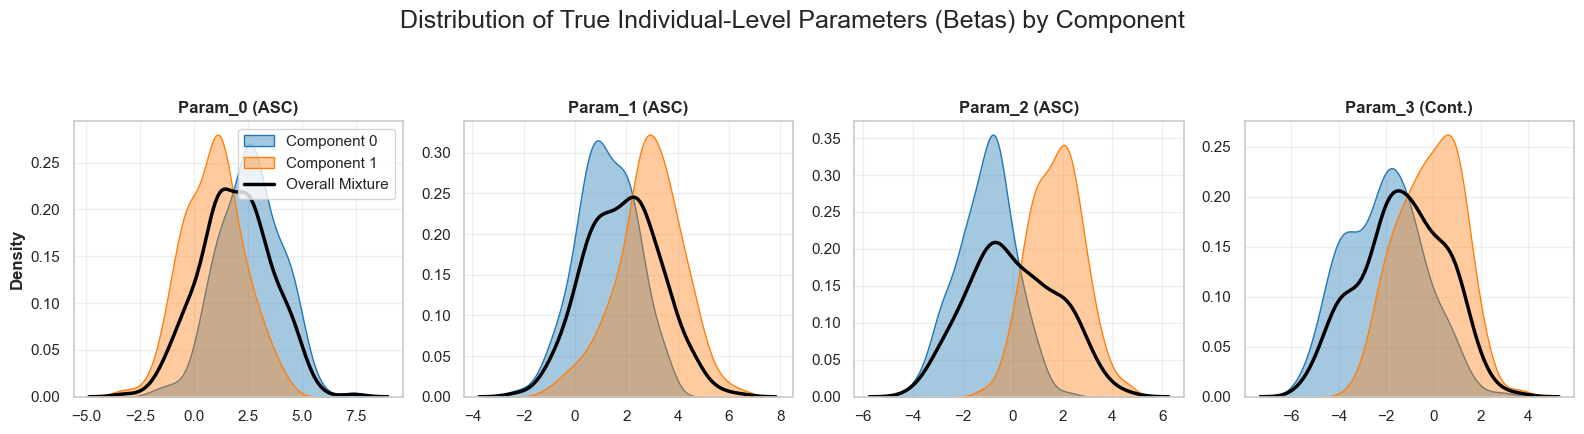

In [5]:
# --- Plotting Individual-Level Parameter Mixtures (Betas) ---
def plot_beta_mixture_distributions(betas, indicators, K, p_names):
    n_params = len(p_names)
    
    # Dynamic sizing based on number of parameters
    fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))
    
    # Ensure axes is iterable even if there is only 1 parameter
    if n_params == 1:
        axes = [axes]
        
    # Generate a distinct color palette for the K components
    colors = sns.color_palette("tab10", K) 
    
    for p in range(n_params):
        ax = axes[p]
        
        # 1. Plot the sub-components first (Filled, behind the overall line)
        for k in range(K):
            comp_betas = betas[indicators == k, p]
            if len(comp_betas) > 1: # Need at least 2 points for KDE
                sns.kdeplot(
                    comp_betas, 
                    ax=ax, 
                    fill=True, 
                    color=colors[k], 
                    alpha=0.4, 
                    label=f"Component {k}"
                )
        
        # 2. Plot the overall mixture distribution on top (Bold Black Line)
        sns.kdeplot(
            betas[:, p], 
            ax=ax, 
            color="black", 
            linewidth=2.5, 
            label="Overall Mixture"
        )
        
        # 3. Apply legacy styling
        ax.set_title(p_names[p], fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        if p == 0:
            ax.set_ylabel("Density", fontweight='bold')
        else:
            ax.set_ylabel("") # Remove redundant y-labels for a cleaner grid
        
        # 4. Add legend only to the first plot, handling duplicate labels
        if p == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
            ax.legend(*zip(*unique), loc='upper right')

    # Apply legacy suptitle formatting
    plt.suptitle("Distribution of True Individual-Level Parameters (Betas) by Component", fontsize=18, y=1.08)
    plt.tight_layout()
    plt.show()

# ==========================================
# Execute the Plot
# ==========================================
print("\nPlotting Beta Mixture Distributions...")

# Extract parameter names dynamically based on your previous design matrix logic
param_names = [f"Param_{i} (ASC)" if i < (A-1) else f"Param_{i} (Cont.)" for i in range(P)]

plot_beta_mixture_distributions(
    betas=sim_data["TRUE_BETA"], 
    indicators=sim_data["TRUE_INDICATORS"], 
    K=sim_data["K"], 
    p_names=param_names
)

In [6]:
# ============================
# 2. MODEL BUILDING
# ============================

def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df,
        scale_tril=scale_tril,
        input_output_cholesky=True,
        validate_args=False
    )


def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )


def build_mixture_hmnl_model(data_dict, A_delta=0.01, a_mu=1.0):
    """
    Builds a Hierarchical MNL model with a mixture of K normals heterogeneity
    distribution, following Rossi et al. (2006) Section 5.5.

    Model (eq. 5.5.1):
        theta_i = Delta' z_i + u_i
        u_i ~ N(mu_{ind_i}, Sigma_{ind_i})
        ind_i ~ Multinomial_K(pvec)           [marginalized out]

    Priors (eq. 5.5.3):
        vec(Delta)  ~ N(0, A_delta^{-1} I)
        pvec        ~ Dirichlet(alpha)
        mu_k        ~ N(0, Sigma_k * a_mu^{-1})
        Sigma_k     ~ IW(nu, V)

    Marginalizing over ind_i gives:
        beta_i ~ sum_k pvec_k * N(Delta' z_i + mu_k, Sigma_k)

    Args:
        data_dict (dict): Dataset dictionary. Must contain 'n_params', 'n_units',
            'K', 'X', 'y', 'unit_idx', and optionally 'Z'.
        A_delta (float): Precision scalar for Delta prior (vec(Delta) ~ N(0, A_delta^{-1} I)).
            Defaults to 0.01.
        a_mu (float): Precision scaling for mu_k prior (mu_k ~ N(0, Sigma_k / a_mu)).
            Defaults to 1.0.

    Returns:
        lsl.Model: A compiled Liesel model.
    """
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    K        = int(data_dict["K"])
    has_Z    = data_dict.get("Z") is not None

    # ------------------------------------------------------------------
    # IW(nu, V) prior on each Sigma_k  <=>  Wishart(nu, V^{-1}) on Sigma_k^{-1}
    # nu > n_params - 1 required for proper prior
    # ------------------------------------------------------------------
    nu = float(n_params + 3)
    V_inv     = jnp.linalg.inv(nu * jnp.eye(n_params))
    Vinv_chol = jnp.linalg.cholesky(V_inv)                              # (n_params, n_params)
    Vinv_chol_K = jnp.broadcast_to(Vinv_chol[None], (K, n_params, n_params))  # (K, n_params, n_params)

    # ==================================================================
    # pvec ~ Dirichlet(alpha)
    # Transformed to unconstrained space via SoftmaxCentered bijector
    # ==================================================================
    alpha = jnp.ones(K) * 2.0   # symmetric Dirichlet, as used in data generation

    pvec = lsl.Var.new_param(
        value=jnp.ones(K) / K,
        distribution=lsl.Dist(tfd.Dirichlet, concentration=alpha),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    # ==================================================================
    # Sigma_k^{-1} ~ Wishart(nu, V^{-1})  for k = 1 ... K
    # Represented as Cholesky factors: shape (K, n_params, n_params)
    # Transformed to unconstrained space via FillScaleTriL bijector
    # ==================================================================
    sigma_inv_chol_k = lsl.Var.new_param(
        value=jnp.array(
            jnp.broadcast_to(jnp.eye(n_params)[None], (K, n_params, n_params))
        ),
        distribution=lsl.Dist(
            make_wishart,
            df=jnp.full(K, nu),          # (K,)   — batched degrees of freedom
            scale_tril=Vinv_chol_K        # (K, n_params, n_params)  — batched scale
        ),
        name="sigma_inv_chol_k"
    )
    sigma_inv_chol_k_latent = sigma_inv_chol_k.transform(
        tfb.FillScaleTriL(),
        name="sigma_inv_chol_k_latent"
    )

    # ==================================================================
    # mu_k ~ N(mu_bar, Sigma_k * a_mu^{-1})  for k = 1 ... K
    # Precision of mu_k = a_mu * Sigma_k^{-1} = a_mu * (L_k L_k^T)
    # Precision factor  = sqrt(a_mu) * L_k    shape (K, n_params, n_params)
    # ==================================================================
    mu_prec_factor_k = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L,
        L=sigma_inv_chol_k,
        name="mu_prec_factor_k"
    )

    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision,
            loc=jnp.zeros(n_params),          # broadcasts to (K, n_params)
            precision_factor=mu_prec_factor_k  # (K, n_params, n_params)
        ),
        name="mu_k"
    )

    # ==================================================================
    # Delta ~ N(0, A_delta^{-1} I)  — demographic shift matrix
    # Precision factor = sqrt(A_delta) * I
    # ==================================================================
    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var   = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")

        Delta_prec_factor = jnp.sqrt(A_delta) * jnp.eye(n_params)  # (n_params, n_params)

        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_demos, n_params)),
            distribution=lsl.Dist(
                make_mvn_precision,
                loc=jnp.zeros(n_params),             # broadcasts to (n_demos, n_params)
                precision_factor=Delta_prec_factor   # (n_params, n_params)
            ),
            name="Delta"
        )

        # Z @ Delta:  (n_units, n_demos) @ (n_demos, n_params) -> (n_units, n_params)
        z_delta = lsl.Var.new_calc(
            lambda z, d: z @ d,
            z=Z_var,
            d=Delta,
            name="z_delta"
        )

    # ==================================================================
    # Derive Chol(Sigma_k) from Chol(Sigma_k^{-1}) for use in MixtureSameFamily.
    #
    # If L_k = Chol(Sigma_k^{-1}), then Sigma_k = (L_k L_k^T)^{-1}.
    # We compute Chol(Sigma_k) numerically via vmap for each component k.
    # A small jitter (1e-6 * I) is added for numerical robustness.
    # ==================================================================
    sigma_chol_k = lsl.Var.new_calc(
        lambda L: jax.vmap(
            lambda Lk: jnp.linalg.cholesky(
                jnp.linalg.inv(Lk @ Lk.T) + 1e-6 * jnp.eye(n_params)
            )
        )(L),
        L=sigma_inv_chol_k,
        name="sigma_chol_k"
    )

    # ==================================================================
    # Marginal distribution of beta_i (indicators marginalized out):
    #
    #   beta_i ~ sum_k pvec_k * N(Delta' z_i + mu_k, Sigma_k)
    #
    # Component locs:  (n_units, K, n_params)
    # Component scale: (1,       K, n_params, n_params)  — broadcast over units
    # ==================================================================
    if has_Z:
        beta_loc = lsl.Var.new_calc(
            lambda zd, mu: zd[:, None, :] + mu[None, :, :],
            zd=z_delta,
            mu=mu_k,
            name="beta_loc"                        # (n_units, K, n_params)
        )
    else:
        beta_loc = lsl.Var.new_calc(
            lambda mu: jnp.broadcast_to(mu[None, :, :], (n_units, K, n_params)),
            mu=mu_k,
            name="beta_loc"                        # (n_units, K, n_params)
        )

    def make_beta_mixture(pvec, locs, scale_trils):
        """
        pvec:        (K,)
        locs:        (n_units, K, n_params)
        scale_trils: (K, n_params, n_params)
        """
        return tfd.MixtureSameFamily(
            mixture_distribution=tfd.Categorical(probs=pvec),
            components_distribution=tfd.MultivariateNormalTriL(
                loc=locs,                       # (n_units, K, n_params)
                scale_tril=scale_trils[None]    # (1, K, n_params, n_params)
            )
        )

    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture,
            pvec=pvec,
            locs=beta_loc,
            scale_trils=sigma_chol_k
        ),
        name="beta_i"
    )

    # ==================================================================
    # Likelihood: y_it ~ Categorical(softmax(X_it @ beta_i))
    # ==================================================================
    X_var   = lsl.Var.new_obs(data_dict["X"],        name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx],
        b=beta_i,
        idx=idx_var,
        name="beta_expanded"
    )
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b),
        x=X_var,
        b=beta_expanded,
        name="logits"
    )
    y_var = lsl.Var.new_obs(
        data_dict["y"],
        distribution=lsl.Dist(tfd.Categorical, logits=logits),
        name="y"
    )

    return lsl.Model([y_var])

In [7]:
# ============================
# 2. Inference
# ============================

def run_mixture_inference(model, data_dict, chains=4, warmup=1000, posterior=2000, seed=123):
    """
    Runs NUTS inference for the mixture of normals HMNL model.

    Parameter blocks and their samplers:
        pvec_latent            — simplex parameters (SoftmaxCentered unconstrained)
        sigma_inv_chol_k_latent — K covariance Cholesky factors (FillScaleTriL unconstrained)
        mu_k                   — K component means
        Delta                  — demographic shift matrix (if Z is present)
        beta_i                 — individual-level parameters

    Args:
        model (lsl.Model): The constructed mixture HMNL model.
        data_dict (dict): Dataset dictionary (used to detect presence of Z).
        chains (int): Number of MCMC chains. Defaults to 4.
        warmup (int): Warmup samples per chain. Defaults to 1000.
        posterior (int): Posterior samples per chain. Defaults to 2000.
        seed (int): Random seed. Defaults to 123.

    Returns:
        tuple: (goose results object, posterior samples dict)
    """
    has_Z = data_dict.get("Z") is not None

    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    # One NUTS kernel per parameter block — matches paper's parameter grouping
    eb.add_kernel(gs.NUTSKernel(["pvec_latent"]))
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_k_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel(["mu_k"]))
    if has_Z:
        eb.add_kernel(gs.NUTSKernel(["Delta"]))
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS Sampling — Mixture of Normals HMNL...")
    engine = eb.build()
    engine.sample_all_epochs()

    return engine.get_results(), engine.get_results().get_posterior_samples()

In [8]:
# ============================
# 4. RUN MODEL
# ============================
print("Building Mixture of Normals HMNL Model...")
choice_data = sim_data

hmnl_model = build_mixture_hmnl_model(choice_data)

start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(
    hmnl_model, choice_data, chains=4, warmup=1000, posterior=2000)

formatted_time = str(datetime.timedelta(seconds=int(time.time() - start_time)))
print(f"Sampling finished in {formatted_time}")

Building Mixture of Normals HMNL Model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling — Mixture of Normals HMNL...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:40<00:00, 13.50s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 1, 2, 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 6, 6, 5, 6 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 4, 2, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 1, 2, 1, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_04: 2, 2, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 290.69chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2, 1, 1, 1 / 25 transitions
liesel.goose.e

Sampling finished in 0:20:22


In [10]:
# ==============================
# 4. DATA PROCESSING & RESHAPING
# ==============================
print("Standardizing array shapes for comparison...")

# Extract dimensions
n_demos = choice_data["n_demos"]
n_params = choice_data["n_params"]
K = choice_data["K"]

# Extract Data Directly from posterior_samples (Label invariance/alignment removed)
delta_samples_reshaped = posterior_samples["Delta"].reshape(-1, n_demos, n_params)
mu_samples = posterior_samples["mu_k"].reshape(-1, K, n_params)

# Reconstruct pvec from the raw latent space
pvec_latent_samples = posterior_samples["pvec_latent"]
bijector_pvec = tfb.SoftmaxCentered()
pvec_samples = bijector_pvec.forward(pvec_latent_samples).reshape(-1, K)

# Prepare True Arrays
true_delta = choice_data["TRUE_DELTA"]
true_mu_k = choice_data["TRUE_MU_K"]
true_pvec = choice_data["TRUE_PVEC"]

print(f"Posterior Shapes -> Mu: {mu_samples.shape}, Delta: {delta_samples_reshaped.shape}, Pvec: {pvec_samples.shape}")
print(f"True Shapes      -> Mu: {true_mu_k.shape},       Delta: {true_delta.shape},       Pvec: {true_pvec.shape}")

Standardizing array shapes for comparison...
Posterior Shapes -> Mu: (8000, 2, 4), Delta: (8000, 2, 4), Pvec: (8000, 2)
True Shapes      -> Mu: (2, 4),       Delta: (2, 4),       Pvec: (2,)



=== MCMC Convergence Summary ===


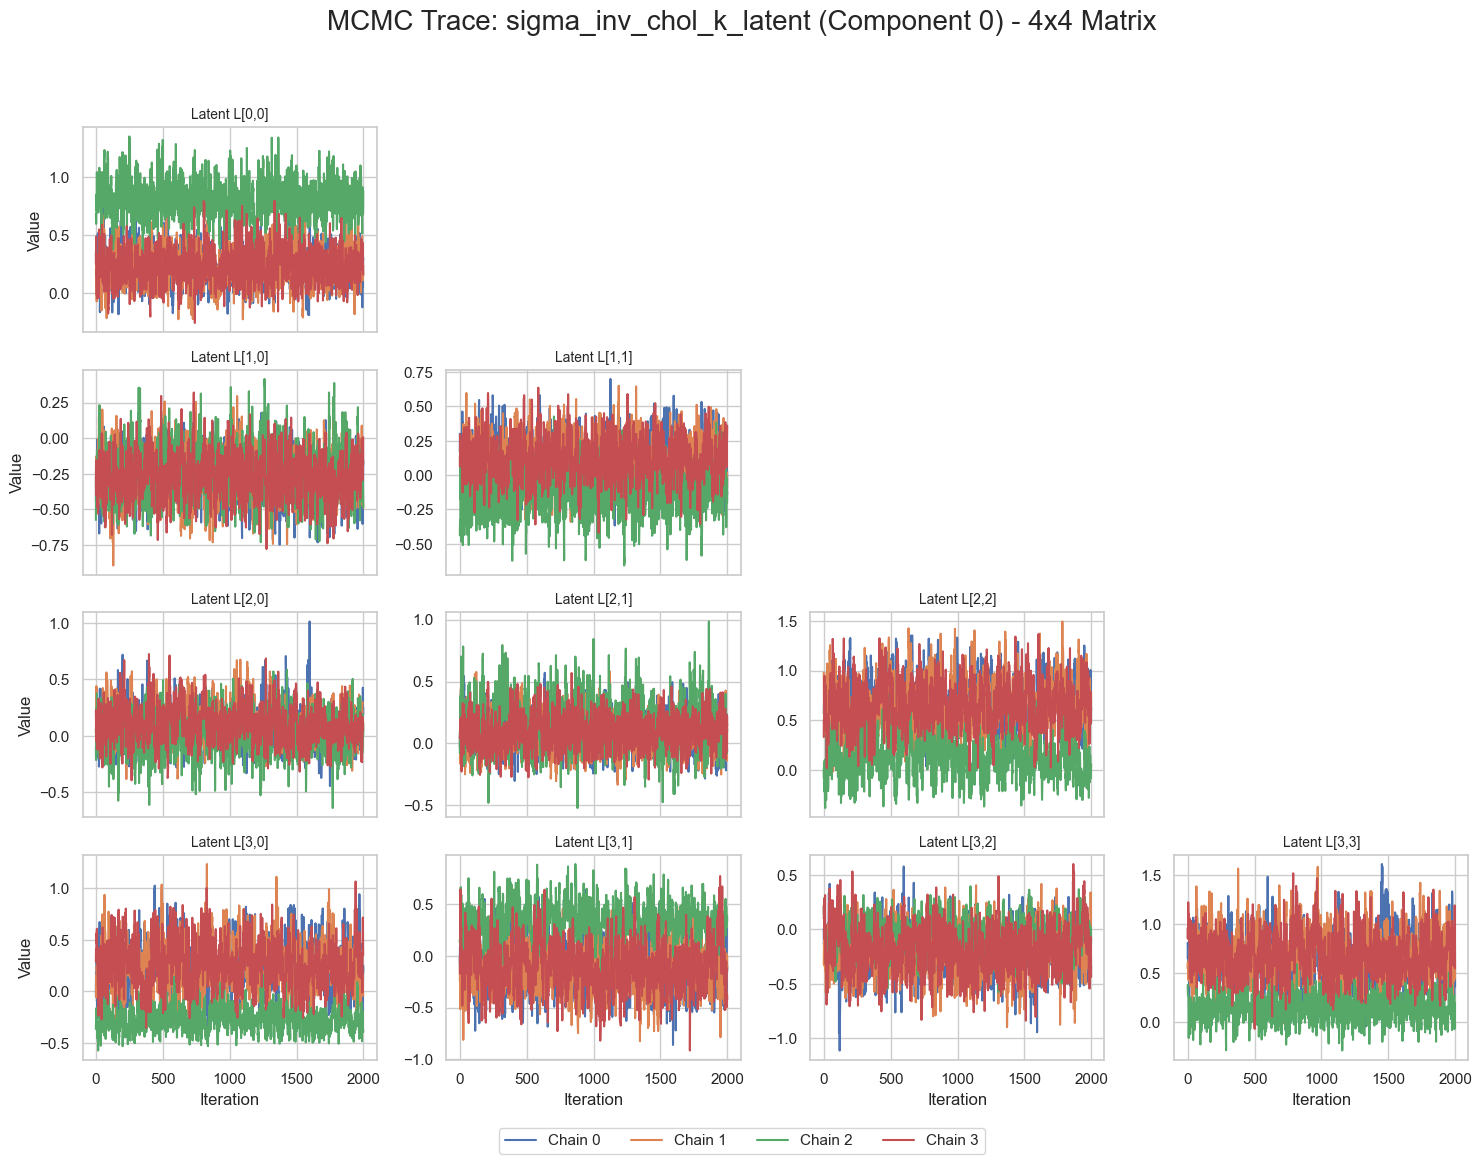

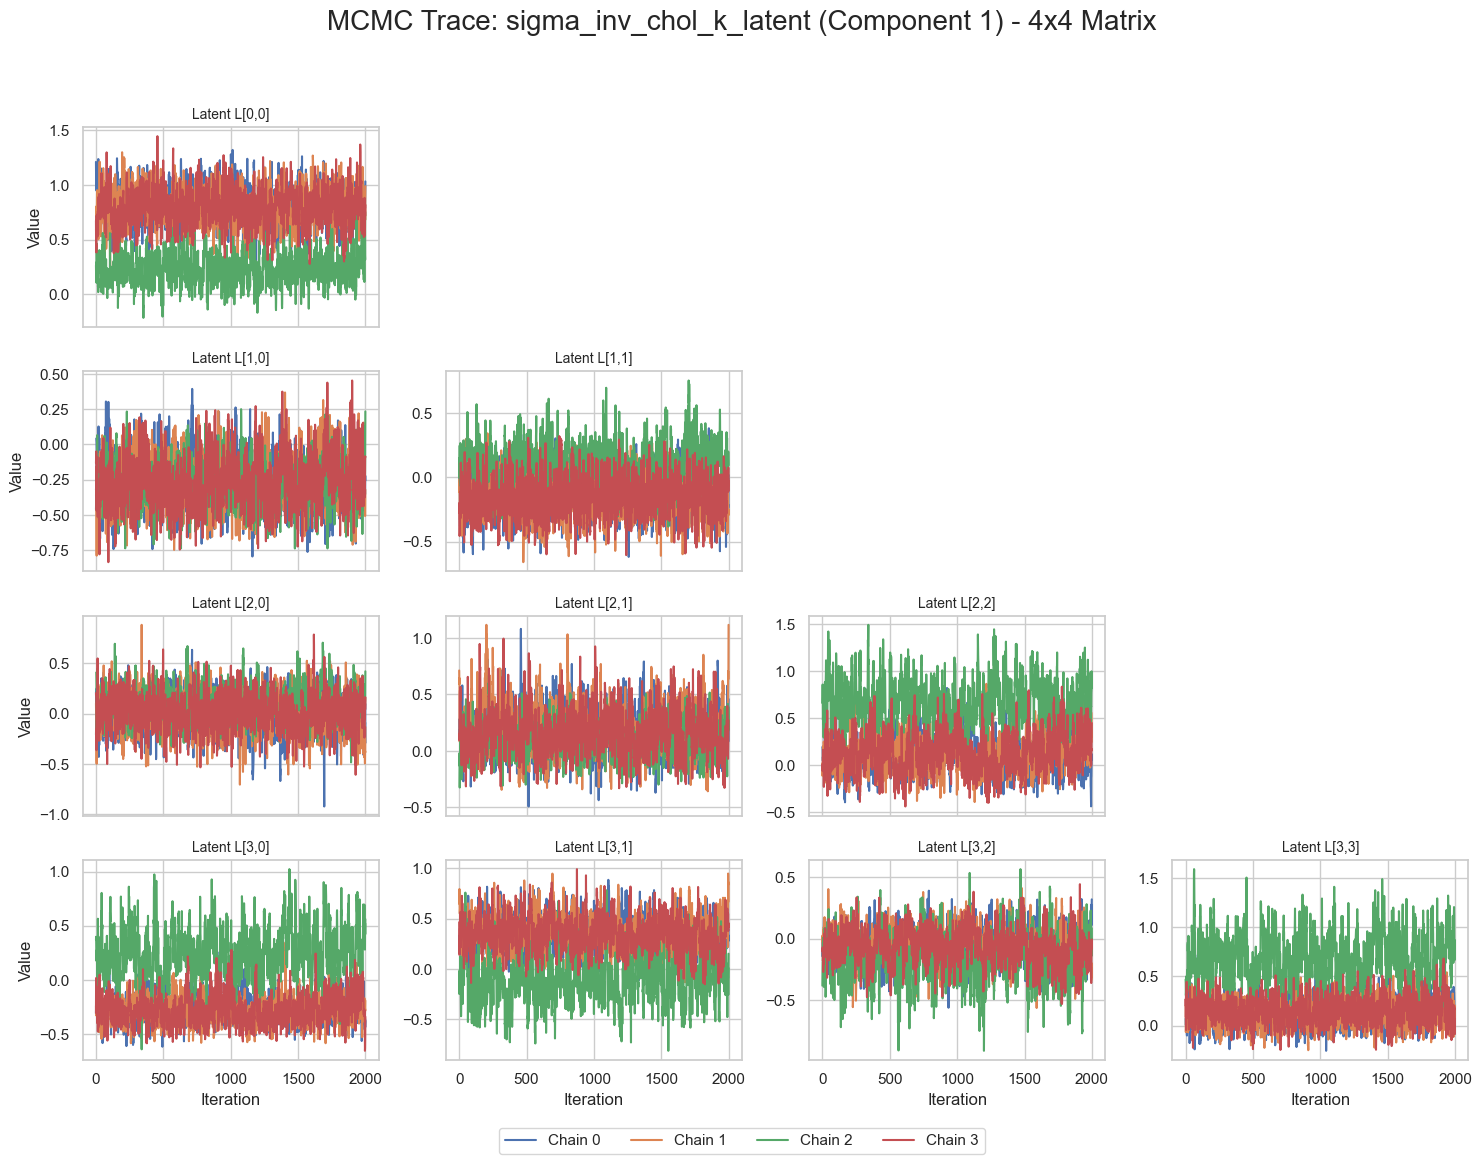

In [11]:
# ==========================================
# 7. MCMC DIAGNOSTICS & TRACE PLOTS
# ==========================================
print("\n=== MCMC Convergence Summary ===")
summary = gs.Summary(mcmc_results)

def plot_cholesky_traces(samples_dict, n_params, k_idx=0, param_name="sigma_inv_chol_k_latent", figsize=(15, 12)):
    # Extract the latent samples and slice for the specific component k
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains, n_draws, n_latent = latent_samples.shape

    # Dynamically create grid based on n_params
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])

    latent_idx = 0

    for i in range(n_params):        # Rows
        for j in range(n_params):    # Columns
            ax = axes[i, j]
            
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(
                        latent_samples[chain, :, latent_idx],
                        label=f"Chain {chain}"
                    )
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')
            
            ax.grid(True)
            if i == n_params - 1 or (i >= j and i + 1 < n_params and i + 1 < j): 
                ax.set_xlabel("Iteration")
            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))

    plt.suptitle(
        f"MCMC Trace: {param_name} (Component {k_idx}) - {n_params}x{n_params} Matrix", 
        fontsize=20
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
    return fig, axes

# Plot traces for each K component
for k in range(K):
    plot_cholesky_traces(
        samples_dict=posterior_samples,  # <-- Using raw posterior samples
        n_params=n_params,
        k_idx=k
    )


Recovering Covariance Matrices (Sigma_k)...


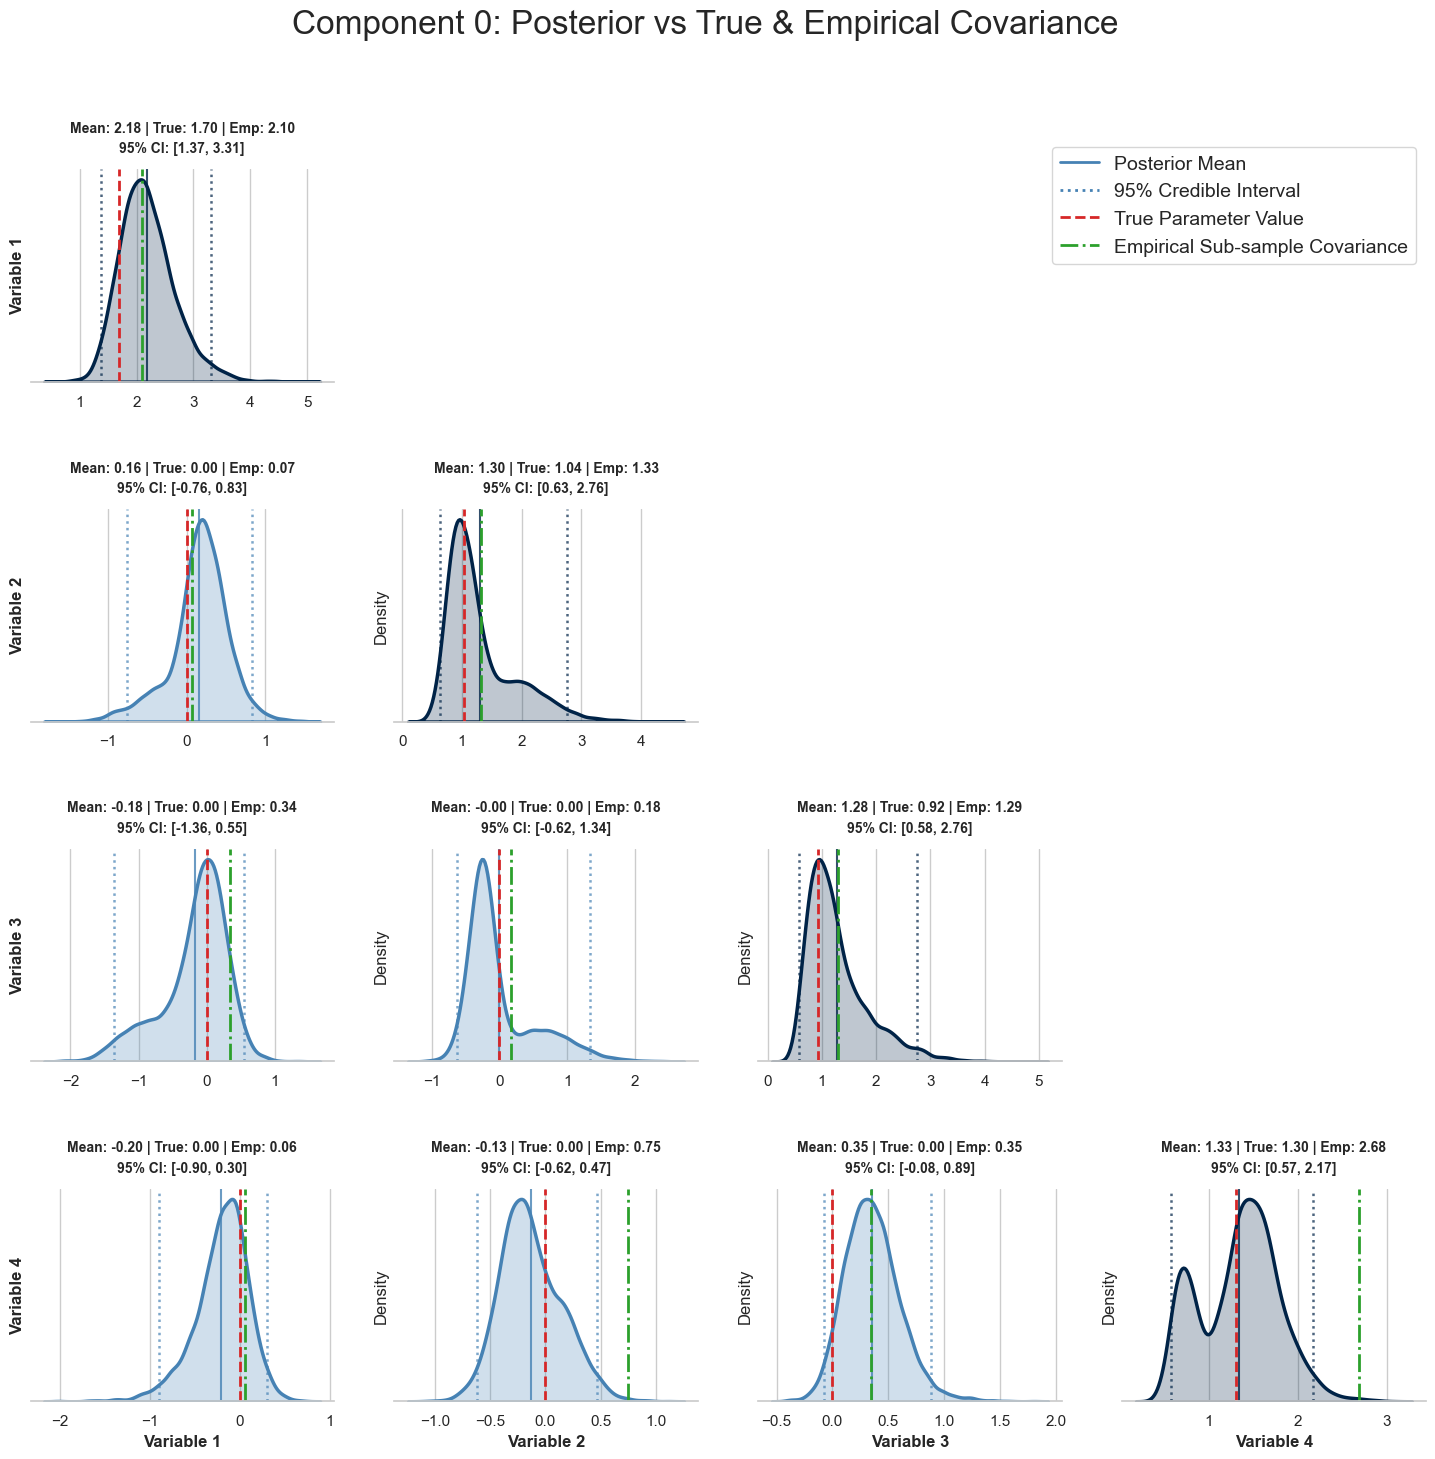

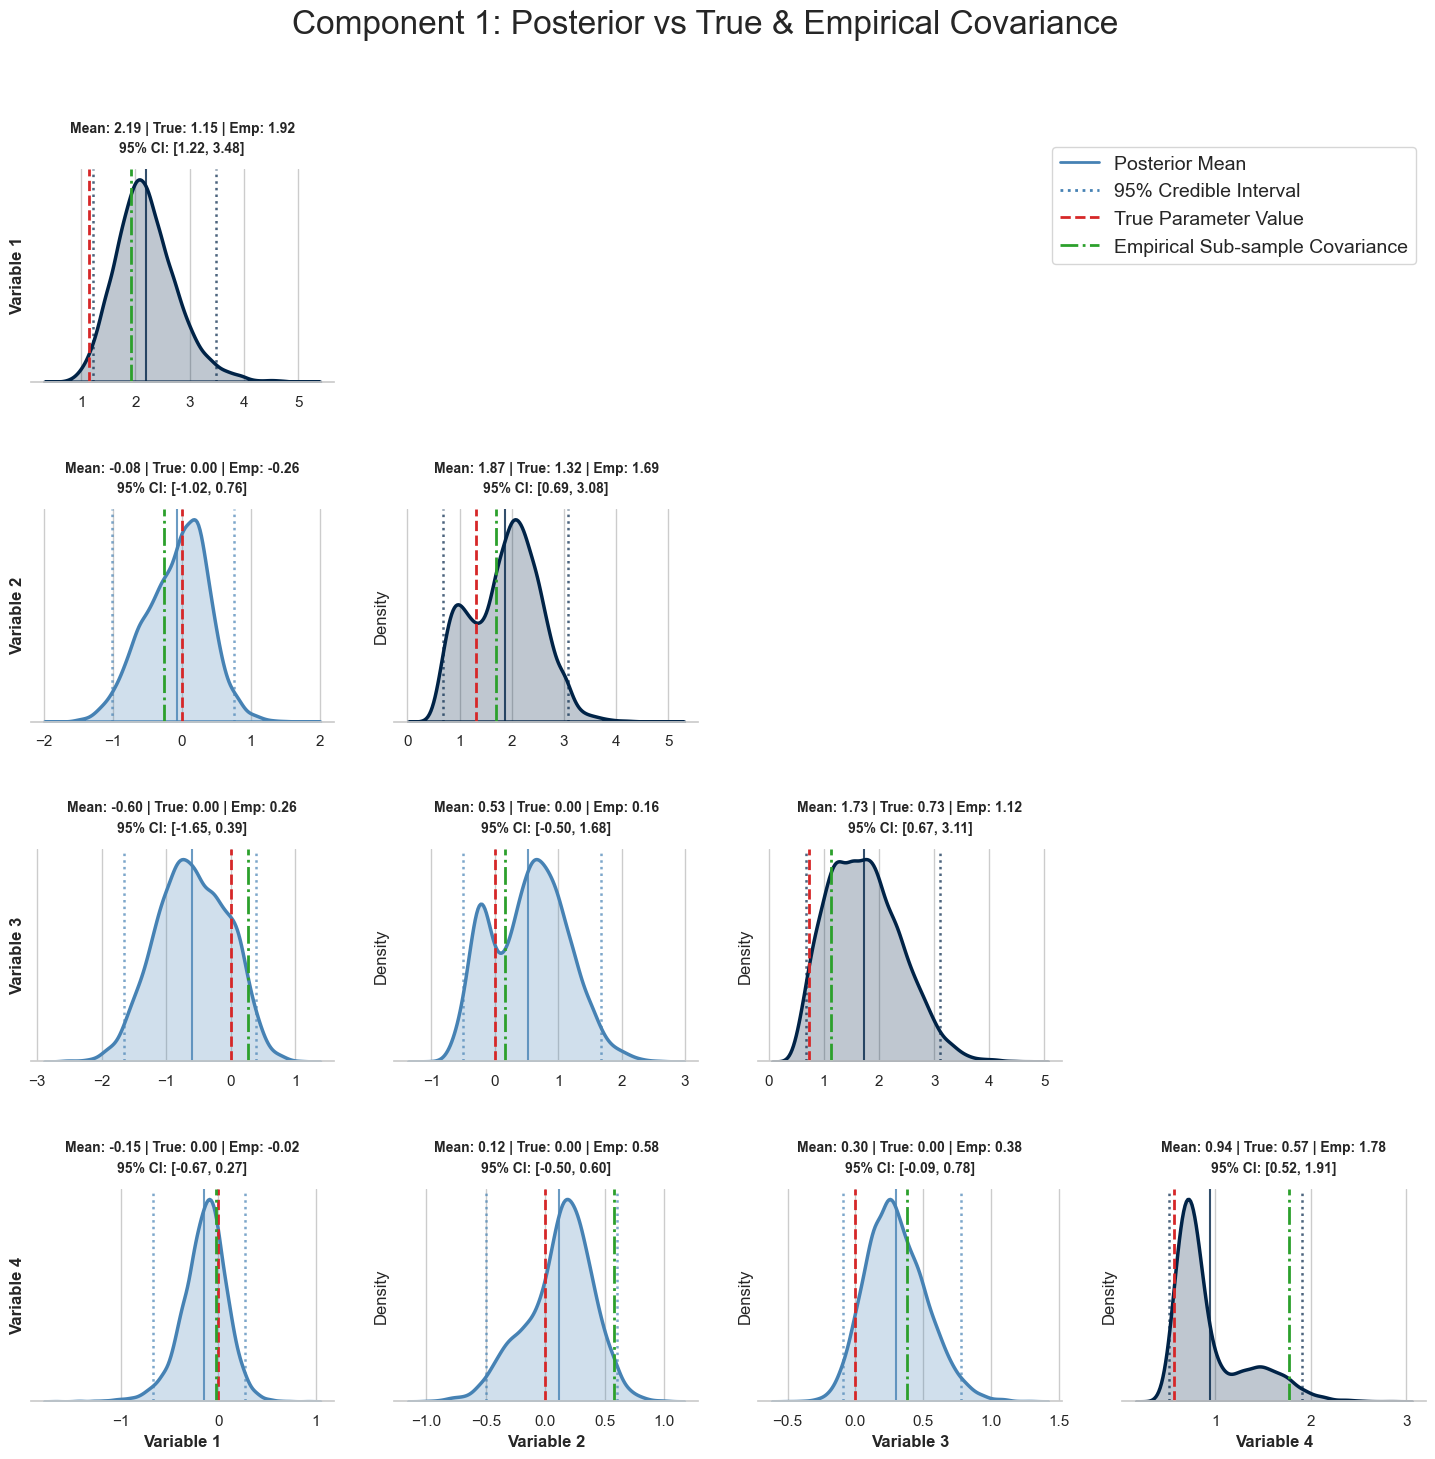

In [12]:
# ==========================================
# 9. COVARIANCE RECOVERY & PLOTTING
# ==========================================
from matplotlib.lines import Line2D
print("\nRecovering Covariance Matrices (Sigma_k)...")

bijector = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

# We need an extra vmap because shape is now (chains, draws, K, latent_dim)
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))

latent_samples = posterior_samples["sigma_inv_chol_k_latent"]
sigma_samples = v_latent_to_sigma(latent_samples) # Shape: (chains, draws, K, P, P)

def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None, component_idx=0):
    n_dim = samples.shape[-1]
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    
    # Flatten across chains and draws
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    diag_color      = "#002347"  
    off_diag_color  = "#4682B4"  
    true_val_color  = "#D62728"  
    emp_val_color   = "#2CA02C"  

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_val:.2f}")
            
            if empirical_matrix is not None:
                emp_val = empirical_matrix[i, j]
                ax.axvline(emp_val, color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {emp_val:.2f}")

            stats_str = " | ".join(title_parts)
            title_str = f"{stats_str}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Sub-sample Covariance')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.9, 0.9), fontsize=14, frameon=True)
    plt.suptitle(f"Component {component_idx}: Posterior vs True & Empirical Covariance", fontsize=24, y=0.98, fontweight='light')
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

for k in range(K):
    # Calculate Empirical Covariance strictly for units assigned to component K
    comp_mask = choice_data["TRUE_INDICATORS"] == k
    comp_betas = choice_data["TRUE_BETA"][comp_mask]
    
    # Only calculate empirical covariance if we have enough observations in this component
    empirical_sigma_k = jnp.cov(comp_betas, rowvar=False) if len(comp_betas) > 1 else None

    plot_final_covariance_complete(
        samples=sigma_samples[:, :, k, :, :], 
        true_matrix=choice_data["TRUE_SIGMA_K"][k], 
        empirical_matrix=empirical_sigma_k,
        component_idx=k
    )


=== Detailed Delta Parameter Diagnostics (Goose Style) ===


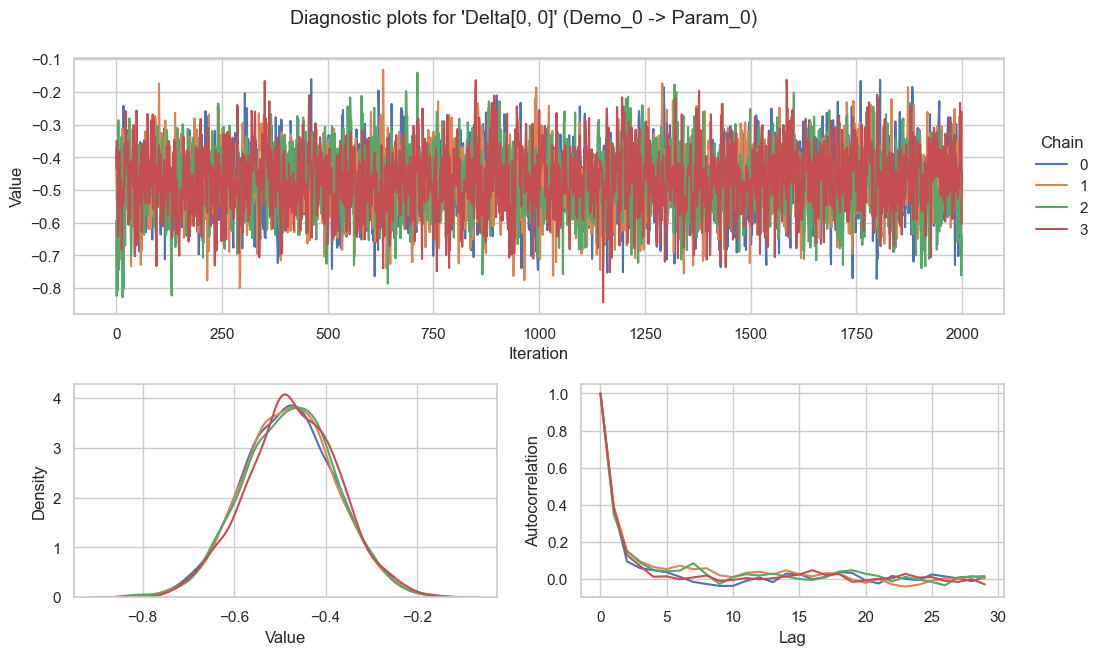

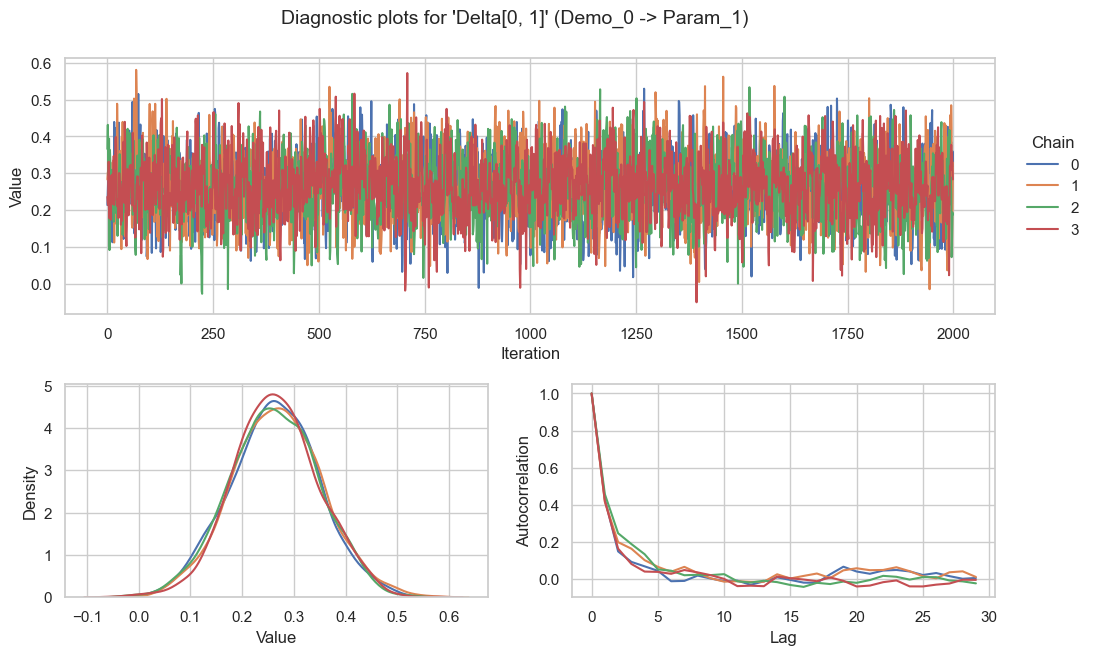

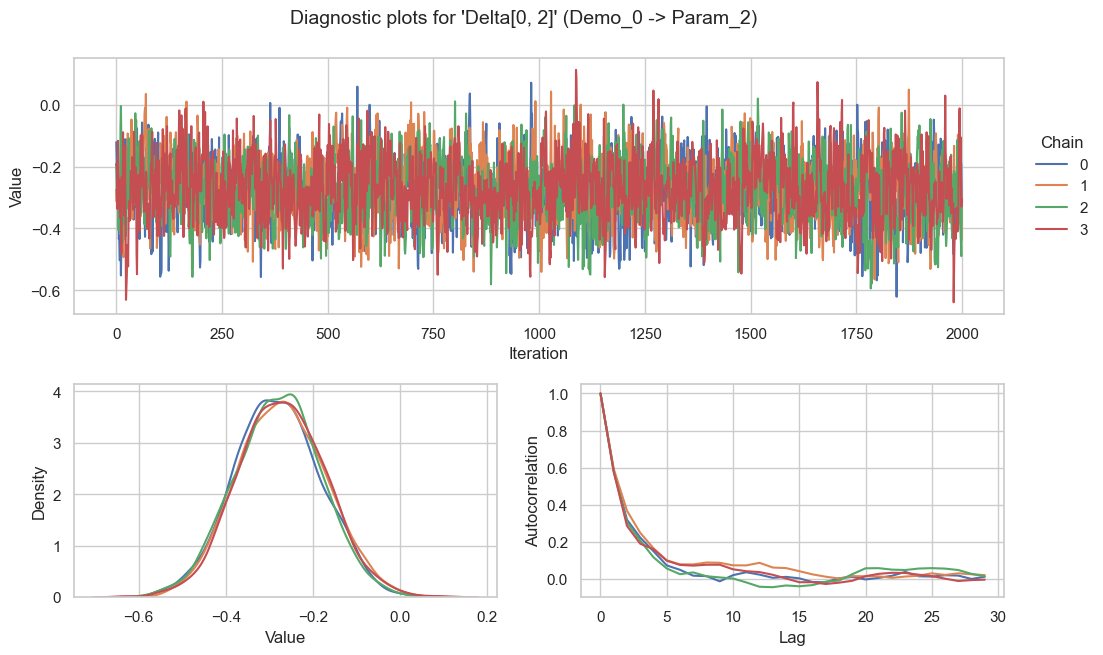

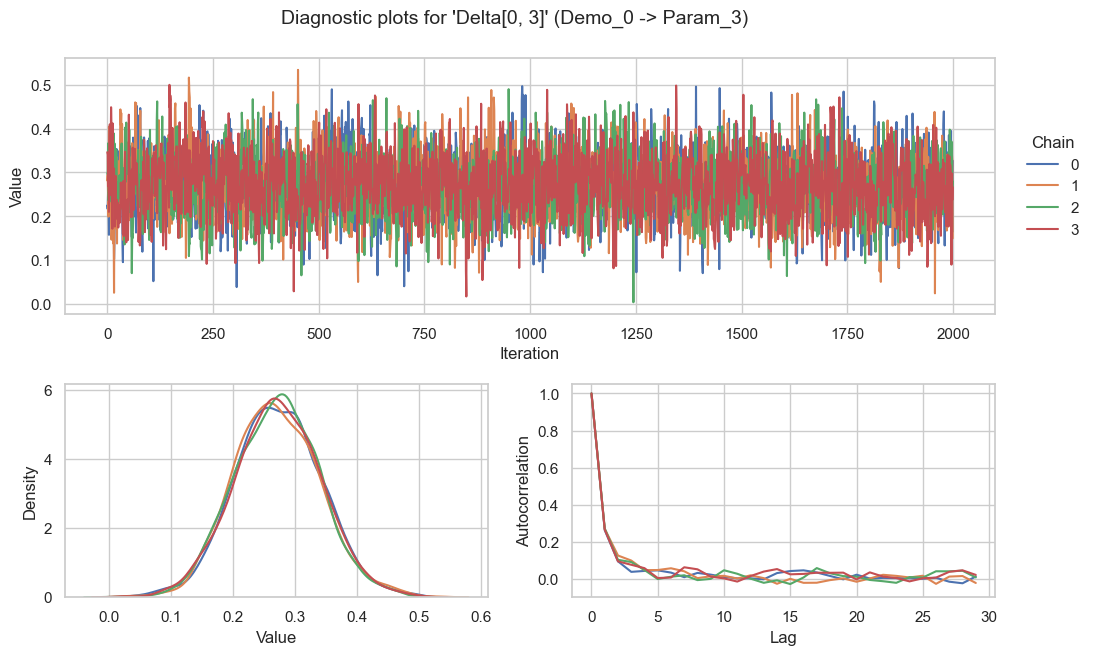

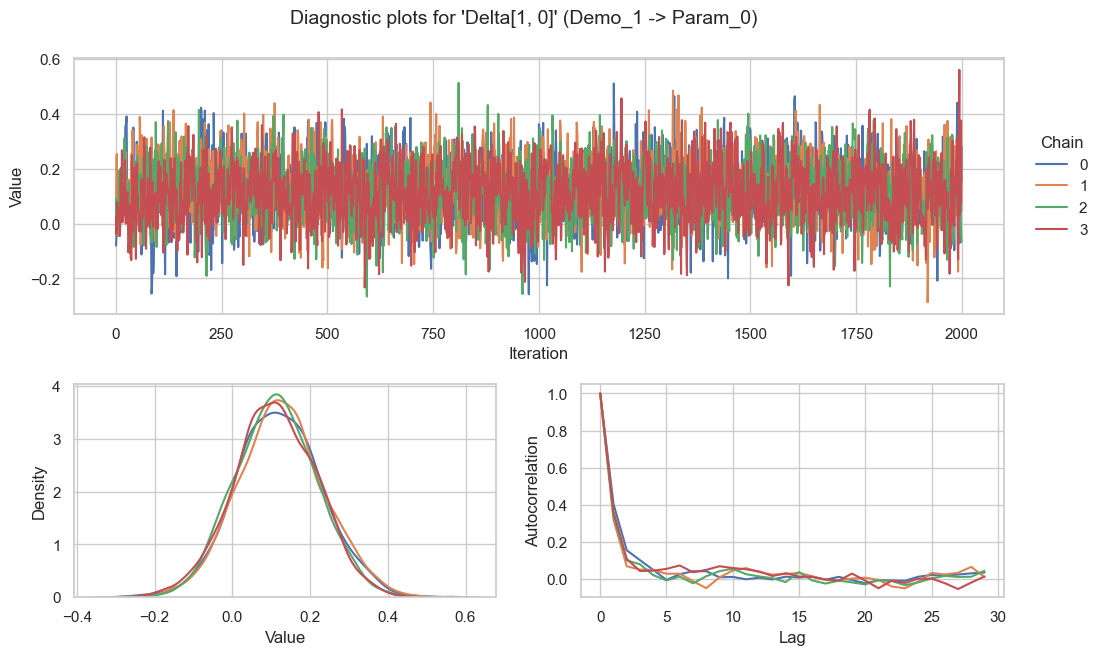

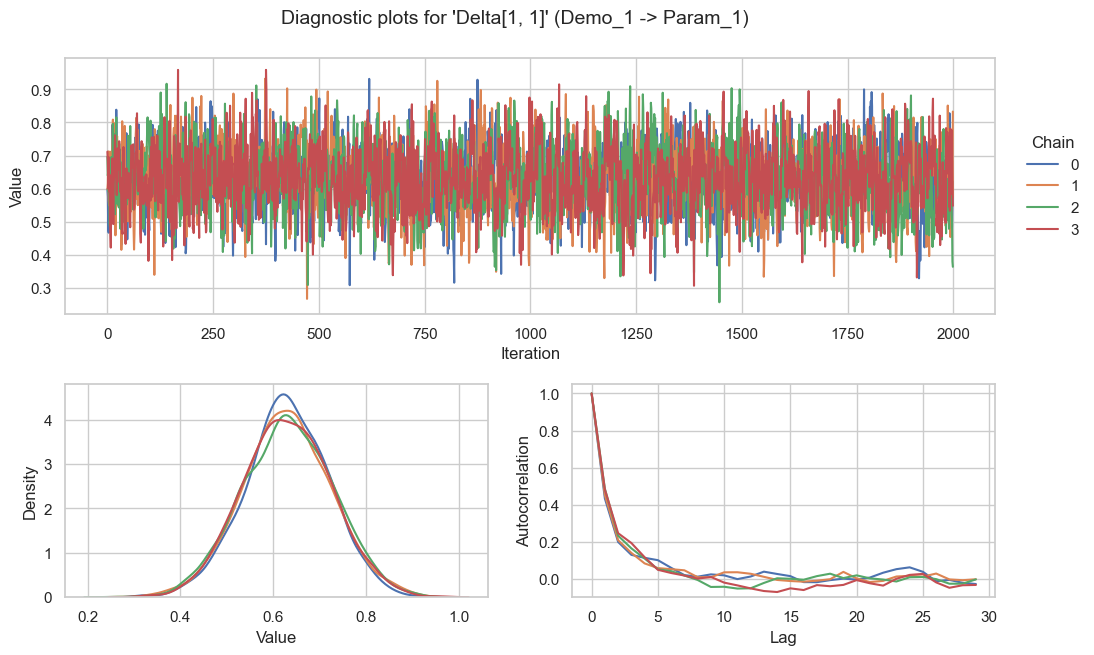

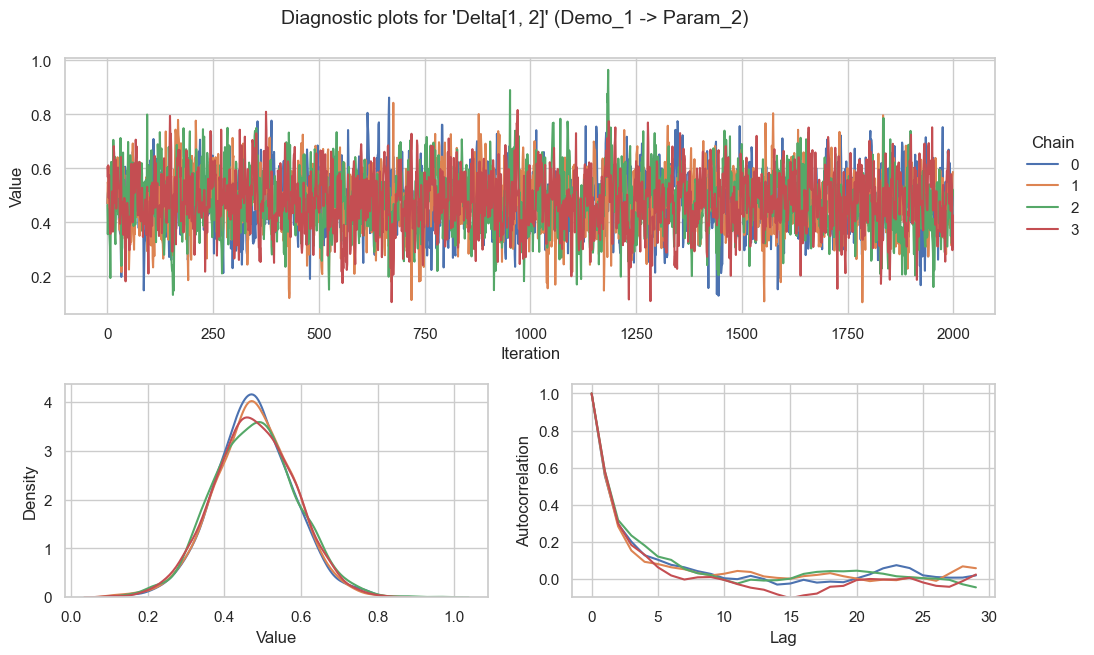

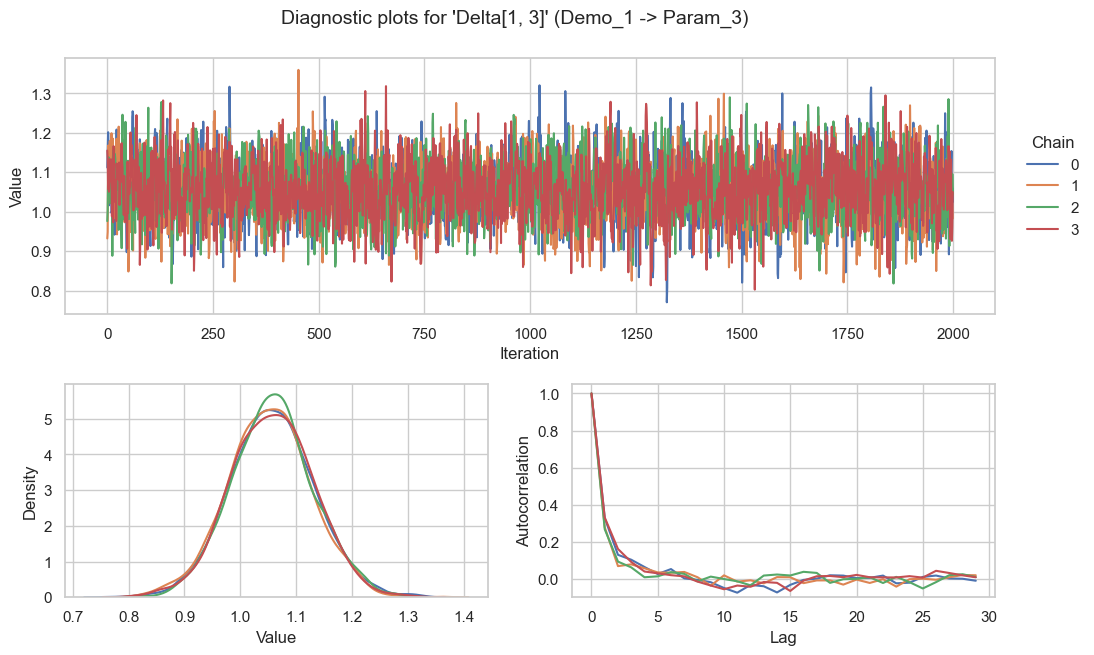

In [13]:
# ============================================
# DETAILED DIAGNOSTICS: GOOSE-STYLE RECREATION
# ============================================

def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm = np.sum(x_centered**2)
    if norm == 0: return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    acf = acf[acf.size // 2:] / norm
    return acf[:nlags]

def plot_goose_style_diagnostics(delta_array, demo_idx, param_idx, demo_name, param_name, n_lags=30):
    n_chains = delta_array.shape[0]
    
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(f"Diagnostic plots for 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})", fontsize=14, y=0.95)
    gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)
    
    ax_trace = fig.add_subplot(gs[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx], label=f"{chain}")
    
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    
    ax_dens = fig.add_subplot(gs[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)
    
    ax_acf = fig.add_subplot(gs[1, 1])
    for chain in range(n_chains):
        acf_vals = compute_acf(delta_array[chain, :, demo_idx, param_idx], nlags=n_lags)
        ax_acf.plot(acf_vals, alpha=1)
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    
    plt.show()

print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
# NOTE: Delta is a global matrix shifting the mixture components. 
# It does not have a K dimension, so the original logic applies directly.
raw_delta_samples = posterior_samples["Delta"]
for i in range(n_demos):
    for j in range(n_params):
        plot_goose_style_diagnostics(
            raw_delta_samples, 
            demo_idx=i, 
            param_idx=j, 
            demo_name=f"Demo_{i}",    # Update with your demo_names if defined globally
            param_name=f"Param_{j}"   # Update with your param_names if defined globally
        )


=== Global Parameters (Baseline Means) Summary Tables ===

--- Component 0 Means ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,2.5266,2.2051,0.3215,0.5376
Param_1,1.0739,1.5303,0.4564,0.7015
Param_2,-1.2251,-0.5811,0.6440,1.1070
Param_3,-2.0395,-1.7663,0.2732,0.8300



--- Component 1 Means ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,1.0687,1.6418,0.5731,0.5474
Param_1,2.6586,2.2971,0.3615,0.7214
Param_2,1.7922,0.6671,1.1251,1.1093
Param_3,-0.2600,-0.8392,0.5792,0.8106



=== True distribution of Delta (Ground Truth) ===


...


=== Posterior distribution of Delta ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.48 (0.10),0.27 (0.09),-0.28 (0.10),0.27 (0.07)
Demo_1,0.12 (0.11),0.63 (0.09),0.48 (0.11),1.06 (0.07)



=== ABSOLUTE DIFFERENCE in Delta (|True - Posterior|) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.104,0.096,0.173,0.055
Demo_1,0.258,0.123,0.019,0.003



Plotting Delta Distributions...


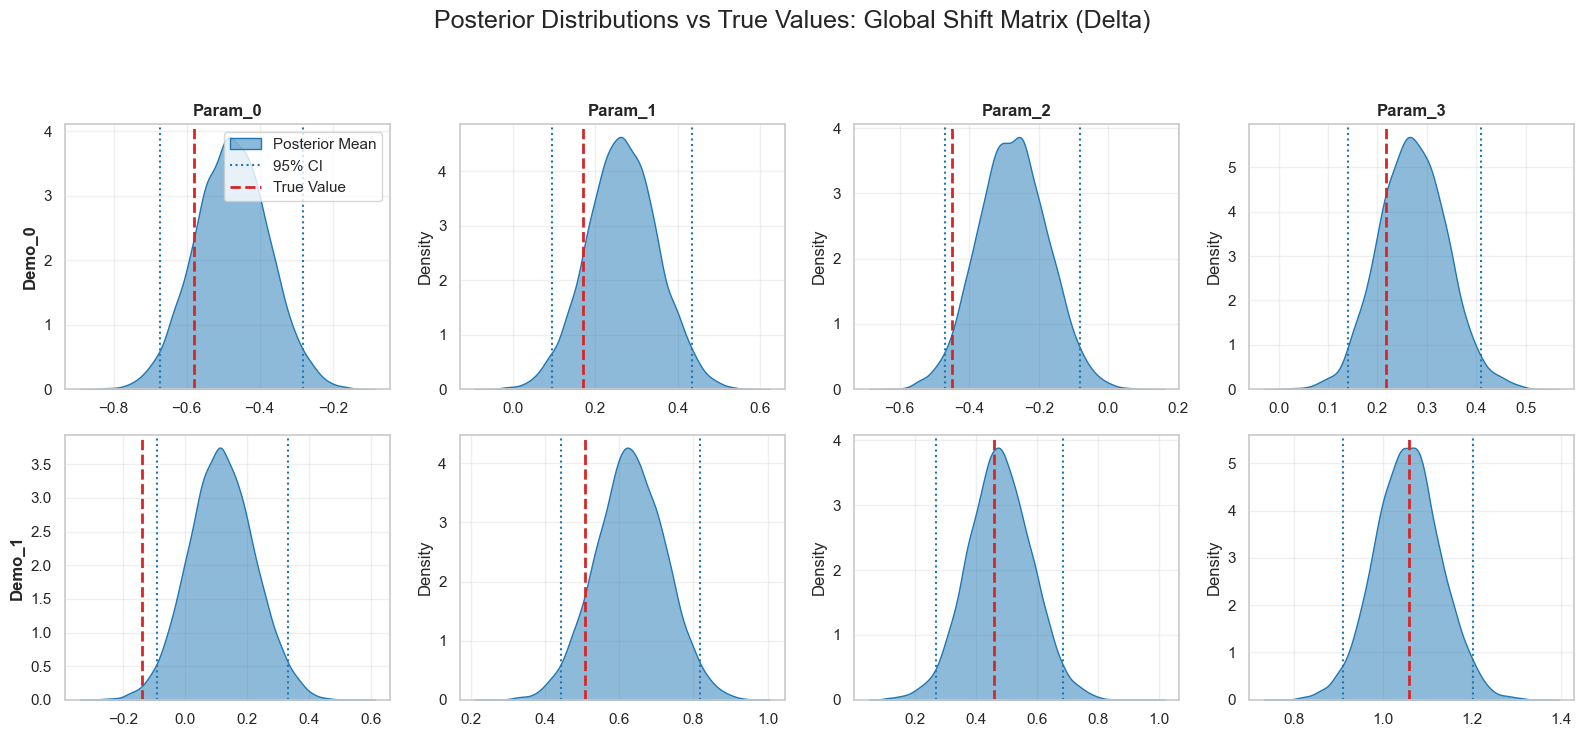

In [14]:
# ============================================
# 5. GLOBAL PARAMETERS: BASELINE MEANS & DELTA
# ============================================

def create_summary_table(t_mu, post_mu, p_names):
    return pd.DataFrame({
        'Parameter': p_names,
        'True_Value': t_mu,
        'Posterior_Mean': post_mu.mean(axis=0),
        'Diff_Abs': np.abs(t_mu - post_mu.mean(axis=0)),
        'Posterior_Std': post_mu.std(axis=0)
    }).round(4).set_index("Parameter")

print("\n=== Global Parameters (Baseline Means) Summary Tables ===")
# Iterate over K to print sub-component means
for k in range(K):
    print(f"\n--- Component {k} Means ---")
    display(create_summary_table(true_mu_k[k], mu_samples[:, k, :], [f"Param_{j}" for j in range(n_params)]))

def generate_delta_table(delta_draws, p_names, d_names):
    mean, std = np.mean(delta_draws, axis=0), np.std(delta_draws, axis=0)
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]: .2f} ({std[i, j]:.2f})"
    return df

def generate_delta_diff_table(t_delta, l_delta, p_names, d_names):
    l_mean = np.mean(l_delta, axis=0)
    diff_mean = np.abs(t_delta - l_mean)
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff_mean[i, j]: .3f}"
    return df

demo_names = [f"Demo_{i}" for i in range(n_demos)]
param_names = [f"Param_{j}" for j in range(n_params)]

print("\n=== True distribution of Delta (Ground Truth) ===")
true_df = pd.DataFrame(true_delta, index=demo_names, columns=param_names)
display(true_df)

print("\n=== Posterior distribution of Delta ===")
display(generate_delta_table(delta_samples_reshaped, param_names, demo_names))

print("\n=== ABSOLUTE DIFFERENCE in Delta (|True - Posterior|) ===")
display(generate_delta_diff_table(true_delta, delta_samples_reshaped, param_names, demo_names))

def plot_delta_distributions(delta_samples, t_delta, p_names, d_names):
    n_demos = len(d_names)
    n_params = len(p_names)
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4*n_params, 3.5*n_demos))
    
    for d in range(n_demos):
        for p in range(n_params):
            ax = axes[d, p] if n_demos > 1 else axes[p]
            samples = delta_samples[:, d, p]
            t_val = t_delta[d, p]
            
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior Mean")
            
            ax.axvline(ci_low, color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)
            ax.axvline(t_val, color="#D62728", linestyle="--", lw=2, label="True Value")
            
            if d == 0: ax.set_title(p_names[p], fontweight='bold')
            if p == 0: ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Posterior Distributions vs True Values: Global Shift Matrix (Delta)", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

print("\nPlotting Delta Distributions...")
plot_delta_distributions(delta_samples_reshaped, true_delta, param_names, demo_names)

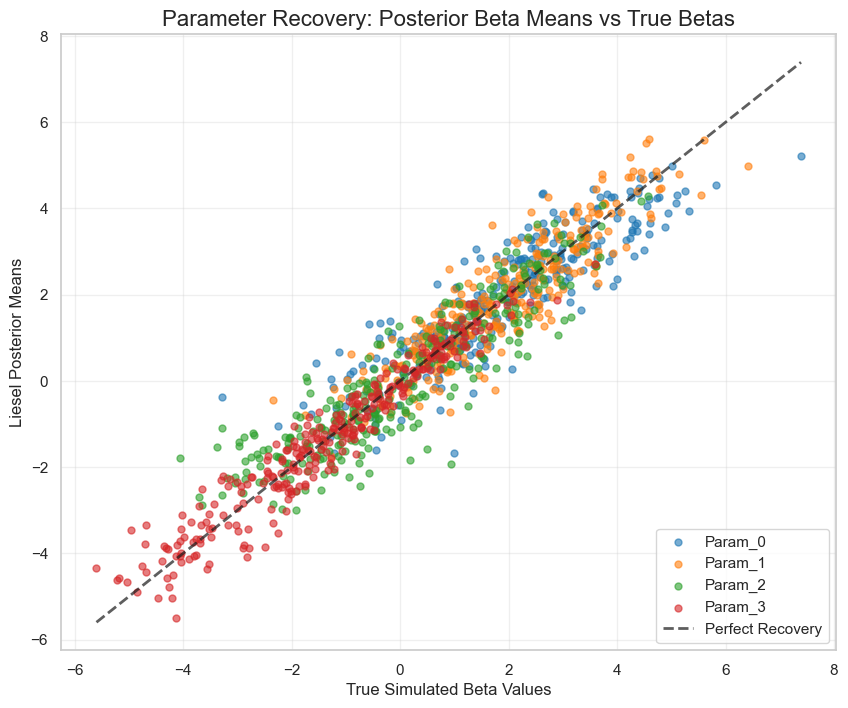


Plotting Household-Level Distributions...


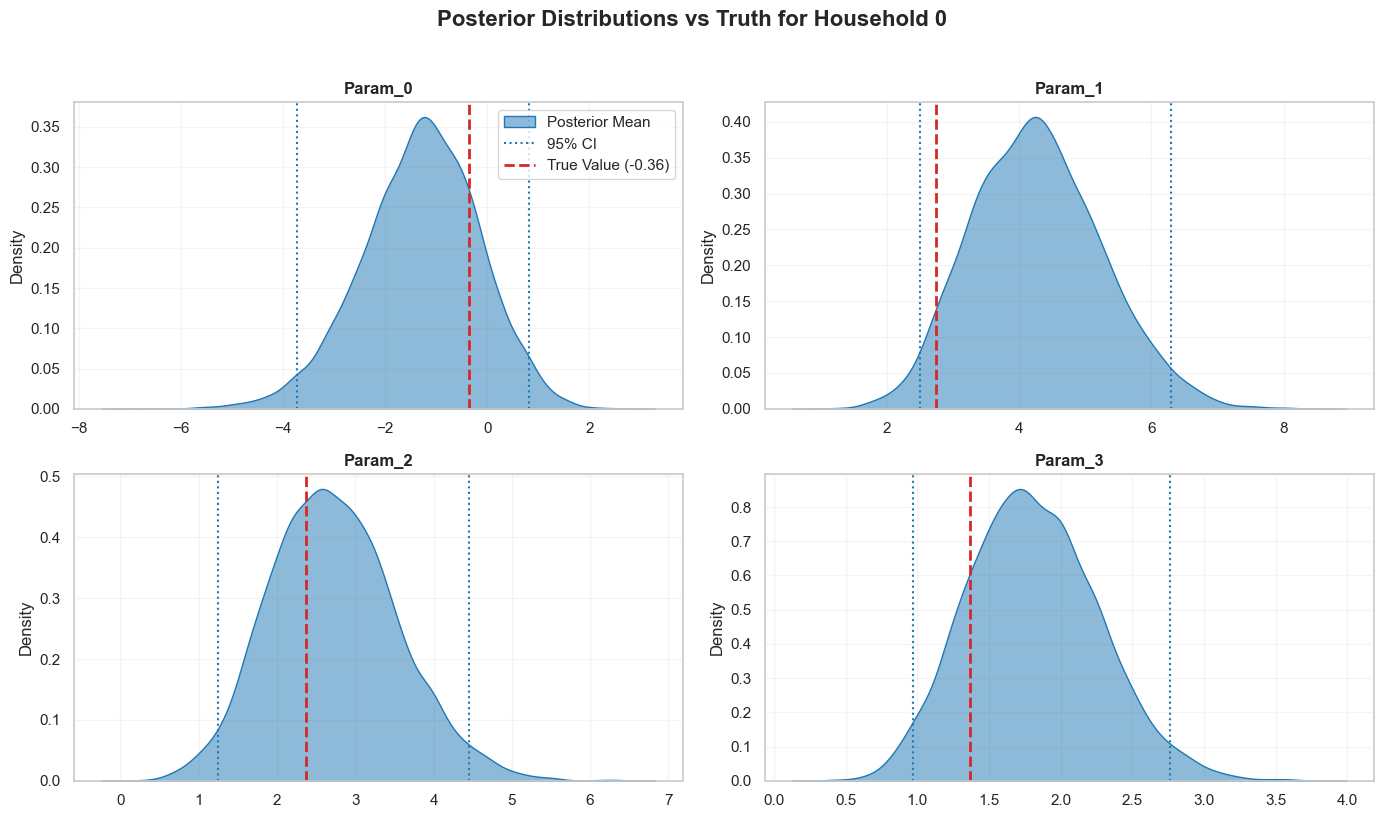

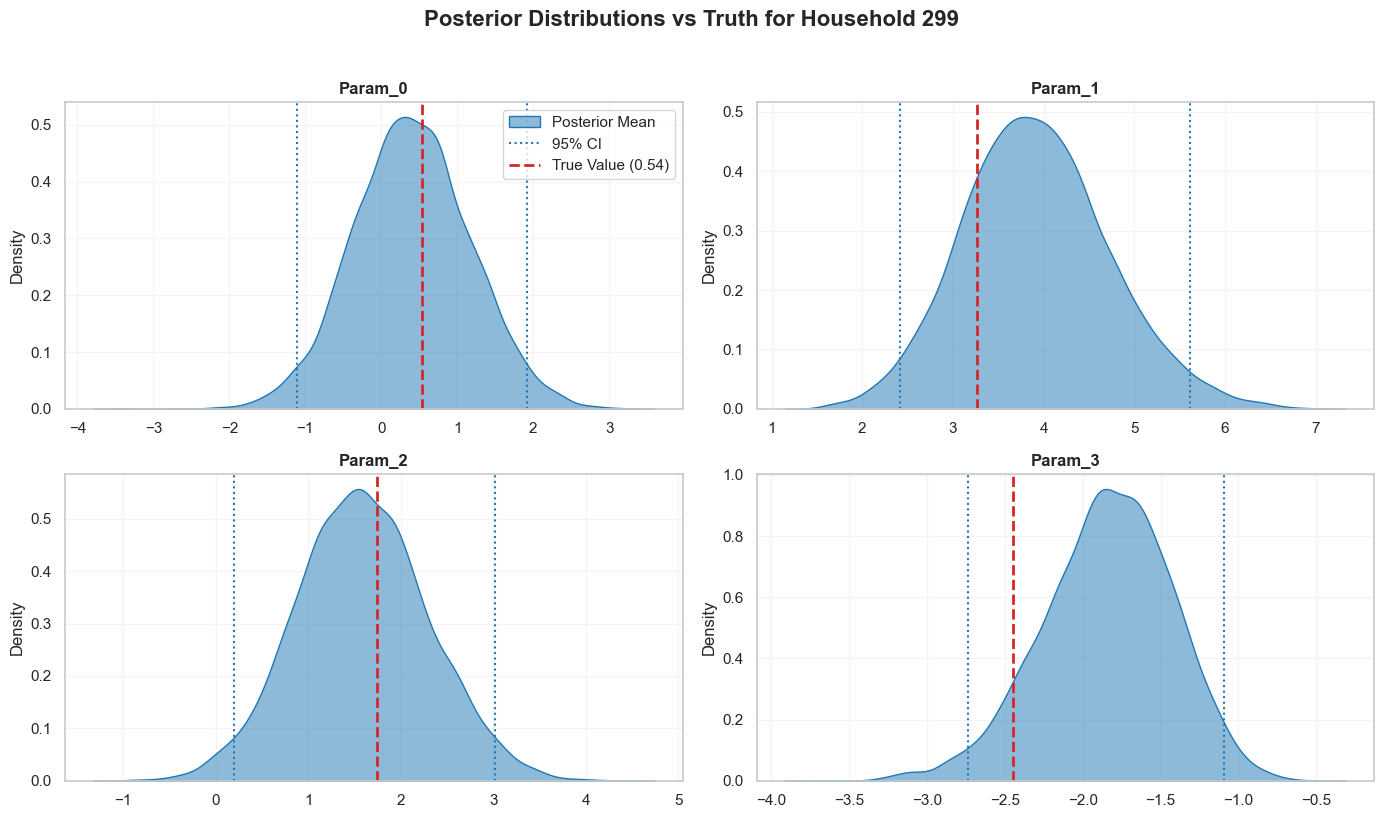

In [15]:
# ==================================
# 6. HOUSEHOLD HETEROGENEITY (BETAS)
# ==================================
# The individual level parameters structural shape remains completely 
# identical under a mixture model (n_units, n_params), so the plotting works universally.

n_chains, n_draws, n_units, n_params = posterior_samples["beta_i"].shape
liesel_beta_full = posterior_samples["beta_i"].reshape(-1, n_units, n_params)
true_betas_full = choice_data["TRUE_BETA"]

l_beta_means = np.mean(liesel_beta_full, axis=0)
l_beta_sds = np.std(liesel_beta_full, axis=0).flatten()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:n_params]
for i, param in enumerate(param_names):
    ax.scatter(true_betas_full[:, i], l_beta_means[:, i], alpha=0.6, s=25, label=param, color=colors[i])

min_val = min(true_betas_full.min(), l_beta_means.min())
max_val = max(true_betas_full.max(), l_beta_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7, label='Perfect Recovery')

ax.set_title("Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values", fontsize=12)
ax.set_ylabel("Liesel Posterior Means", fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

def plot_beta_distributions(samples, true_vals, p_names, title_prefix, color_l="#1f77b4", color_t="#d62728"):
    cols = 2
    rows = int(np.ceil(len(p_names) / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    if len(p_names) == 1: axes = np.array([axes])
    
    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue
            
        l_vals = samples[:, i]
        t_val = true_vals[i]
        
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])
        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.5, label="Posterior Mean")
        
        ax.axvline(ci_low, color=color_l, linestyle=":", lw=1.5, label="95% CI")
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)
        ax.axvline(t_val, color=color_t, linestyle="--", lw=2, label=f"True Value ({t_val:.2f})")
        
        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)
        
        if i == 0: 
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for j, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:j]]
            ax.legend(*zip(*unique), loc="upper right")
        
    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\nPlotting Household-Level Distributions...")
plot_beta_distributions(
    liesel_beta_full[:, 0, :], 
    true_betas_full[0, :], 
    param_names, 
    "Posterior Distributions vs Truth for Household 0"
)

plot_beta_distributions(
    liesel_beta_full[:, -1, :], 
    true_betas_full[-1, :], 
    param_names, 
    f"Posterior Distributions vs Truth for Household {n_units-1}"
)